# Multimodal Qwen Agent Lab: local + remote Ollama

## Goal

Exercise one small agent path with three inputs:

- **Text:** send an English or Korean instruction directly to Qwen.
- **Visual:** send a local image to Qwen's vision input.
- **Vocal:** record or load audio, transcribe it locally with Whisper, then send the transcript to Qwen.

The same code can target a lightweight Ollama model on this Mac or a heavier model on another Mac through an SSH tunnel. The final section also gives Qwen a real local tool backed by this project's `YOLO_World_Manager`.

```text
text / image / Whisper transcript
              |
        Qwen via Ollama
       local or SSH tunnel
              | tool call
       local YOLO-World model
```

## Setup

### 1. Prepare Ollama

On this Mac, install and start Ollama, then pull the lightweight model:

```bash
ollama pull qwen3.5:2b
```

On the other Mac, start Ollama and pull a larger model:

```bash
ollama pull qwen3.5:9b
```

### 2. Open the SSH tunnel for remote inference

Run this in a separate terminal on this Mac and leave it open:

```bash
ssh -N -L 11435:127.0.0.1:11434 <user>@<remote-mac>
```

The remote Ollama server can remain bound to loopback; there is no need to expose port 11434 to the LAN. Set `ODIA_AGENT_BACKEND=remote` before launching Jupyter to select it. The default is `local`.

### 3. Launch the notebook

```bash
uv sync --locked
uv run jupyter lab notebooks/multimodal_agent_lab/local_remote_qwen_agent.ipynb
```

## Steps

### 1. Imports and visible configuration

Environment variables make the notebook portable without hiding important parameters in global machine configuration.

In [1]:
from __future__ import annotations

import json
import os
import time
from pathlib import Path
from typing import Any

import numpy as np
import ollama
import sounddevice as sd
import soundfile as sf
import whisper
from IPython.display import Audio, Image, Markdown, display


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the detect_objects repository")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SAMPLE_IMAGE = PROJECT_ROOT / "src/detect_objects/models/image.png"
SAMPLE_AUDIO = PROJECT_ROOT / "samples/audio/cat_meow.wav"
RECORDED_AUDIO = PROJECT_ROOT / "outputs/notebook_voice_command.wav"

BACKEND = os.getenv("ODIA_AGENT_BACKEND", "local").strip().lower()
if BACKEND not in {"local", "remote"}:
    raise ValueError("ODIA_AGENT_BACKEND must be 'local' or 'remote'")

OLLAMA_HOSTS = {
    "local": os.getenv("ODIA_LOCAL_OLLAMA_HOST", "http://127.0.0.1:11434"),
    "remote": os.getenv("ODIA_REMOTE_OLLAMA_HOST", "http://127.0.0.1:11435"),
}
MODELS = {
    "local": os.getenv("ODIA_LOCAL_QWEN_MODEL", "qwen3.5:2b"),
    "remote": os.getenv("ODIA_REMOTE_QWEN_MODEL", "qwen3.5:9b"),
}

print(f"project: {PROJECT_ROOT}")
print(f"selected backend: {BACKEND}")
print(f"endpoint: {OLLAMA_HOSTS[BACKEND]}")
print(f"model: {MODELS[BACKEND]}")

project: /Users/kafka/Github_/odia-project/detect_objects
selected backend: local
endpoint: http://127.0.0.1:11434
model: qwen3.5:2b


### 2. Check local and tunneled Ollama endpoints

This check never downloads a model. It reports whether each server is reachable and whether its configured model is already present.

In [2]:
clients = {name: ollama.Client(host=host) for name, host in OLLAMA_HOSTS.items()}
server_status: dict[str, dict[str, Any]] = {}

for name, client in clients.items():
    try:
        listed_models = client.list().models
        installed = {
            getattr(item, "model", None) or getattr(item, "name", None)
            for item in listed_models
        }
        server_status[name] = {
            "reachable": True,
            "model": MODELS[name],
            "model_installed": MODELS[name] in installed,
            "installed_models": sorted(model for model in installed if model),
        }
    except Exception as error:
        server_status[name] = {
            "reachable": False,
            "model": MODELS[name],
            "model_installed": False,
            "error": f"{type(error).__name__}: {error}",
        }

print(json.dumps(server_status, indent=2, ensure_ascii=False))
SELECTED_READY = bool(
    server_status[BACKEND]["reachable"]
    and server_status[BACKEND]["model_installed"]
)
if not SELECTED_READY:
    print(f"\nSelected backend is not ready. Follow the Setup section, then rerun this cell.")

{
  "local": {
    "reachable": false,
    "model": "qwen3.5:2b",
    "model_installed": false,
    "error": "ConnectionError: Failed to connect to Ollama. Please check that Ollama is downloaded, running and accessible. https://ollama.com/download"
  },
  "remote": {
    "reachable": false,
    "model": "qwen3.5:9b",
    "model_installed": false,
    "error": "ConnectionError: Failed to connect to Ollama. Please check that Ollama is downloaded, running and accessible. https://ollama.com/download"
  }
}

Selected backend is not ready. Follow the Setup section, then rerun this cell.


### 3. Text input

The instruction mixes Korean and English class names intentionally; this resembles the project's Whisper-to-YOLO command path.

In [3]:
TEXT_PROMPT = (
    "사용자가 '사람과 휴대폰을 감시해 줘'라고 말했습니다. "
    "YOLO-World에 전달할 English class names를 짧은 JSON 배열로 답하세요."
)

if SELECTED_READY:
    started_at = time.perf_counter()
    text_response = clients[BACKEND].chat(
        model=MODELS[BACKEND],
        messages=[{"role": "user", "content": TEXT_PROMPT}],
        think=False,
    )
    text_latency = time.perf_counter() - started_at
    print(text_response.message.content)
    print(f"\nlatency: {text_latency:.2f}s via {BACKEND}")
else:
    print("Skipped: selected Ollama backend/model is not ready.")

Skipped: selected Ollama backend/model is not ready.


### 4. Visual input

The Python client encodes the local image in the API request. With `BACKEND=remote`, the image bytes travel through the encrypted SSH tunnel to the other Mac. This direct vision call is useful for comparison; the live application should continue using YOLO for per-frame detection.

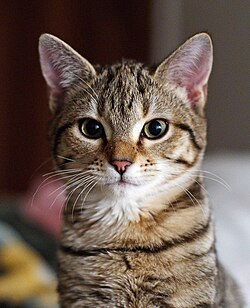

Inference skipped: the image display above still verifies the local input path.


In [4]:
display(Image(filename=str(SAMPLE_IMAGE), width=320))

if SELECTED_READY:
    started_at = time.perf_counter()
    visual_response = clients[BACKEND].chat(
        model=MODELS[BACKEND],
        messages=[
            {
                "role": "user",
                "content": (
                    "List the visible objects concisely. Separate direct observations "
                    "from uncertain guesses."
                ),
                "images": [str(SAMPLE_IMAGE)],
            }
        ],
        think=False,
    )
    visual_latency = time.perf_counter() - started_at
    print(visual_response.message.content)
    print(f"\nlatency: {visual_latency:.2f}s via {BACKEND}")
else:
    print("Inference skipped: the image display above still verifies the local input path.")

### 5. Vocal input: microphone or reproducible sample

For a real voice test, change `RECORD_LIVE_VOICE` to `True`, run the cell, and speak for five seconds. Microphone recording is opt-in so a top-to-bottom notebook run never activates hardware unexpectedly. With the default `False`, the existing cat sample smoke-tests audio loading and Whisper; because it contains no speech, an empty or bracketed transcript is acceptable. You can also set `VOICE_AUDIO_PATH` to any WAV file.

In [5]:
RECORD_LIVE_VOICE = False
RECORD_SECONDS = 5
SAMPLE_RATE = 16_000


def record_microphone(output_path: Path, seconds: int = 5) -> Path:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    print(f"Recording for {seconds} seconds...")
    samples = sd.rec(
        int(seconds * SAMPLE_RATE),
        samplerate=SAMPLE_RATE,
        channels=1,
        dtype="float32",
    )
    sd.wait()
    sf.write(output_path, np.squeeze(samples), SAMPLE_RATE)
    print(f"Saved: {output_path}")
    return output_path


configured_voice_path = os.getenv("VOICE_AUDIO_PATH")
if RECORD_LIVE_VOICE:
    voice_audio_path = record_microphone(RECORDED_AUDIO, RECORD_SECONDS)
elif configured_voice_path:
    voice_audio_path = Path(configured_voice_path).expanduser().resolve()
else:
    voice_audio_path = SAMPLE_AUDIO

if not voice_audio_path.exists():
    raise FileNotFoundError(voice_audio_path)

print(f"audio input: {voice_audio_path}")
display(Audio(filename=str(voice_audio_path)))

audio input: /Users/kafka/Github_/odia-project/detect_objects/samples/audio/cat_meow.wav


In [6]:
whisper_model = whisper.load_model("base", device="cpu")
transcription = whisper_model.transcribe(
    str(voice_audio_path),
    fp16=False,
    language=None,
)
voice_text = transcription["text"].strip()
print(f"Whisper transcript: {voice_text!r}")

if SELECTED_READY and voice_text:
    vocal_response = clients[BACKEND].chat(
        model=MODELS[BACKEND],
        messages=[
            {
                "role": "system",
                "content": "You convert spoken camera-monitoring requests into concise actions.",
            },
            {"role": "user", "content": voice_text},
        ],
        think=False,
    )
    print(f"Qwen response: {vocal_response.message.content}")
elif not voice_text:
    print("No speech was transcribed; record a voice command or set VOICE_AUDIO_PATH.")
else:
    print("Qwen step skipped: selected Ollama backend/model is not ready.")

Whisper transcript: 'RUN! RUN! RUN! RUN!'
Qwen step skipped: selected Ollama backend/model is not ready.


### 6. Agent tool call: Qwen chooses classes, local YOLO observes

This is the important distributed-system boundary. Qwen may run locally or on the other Mac, but the `detect_sample_image` tool always executes next to the camera and YOLO weights on this Mac. Only the tool schema, arguments, and compact detection result enter the LLM conversation.

In [7]:
from detect_objects.models.yolo_world_module import YOLO_World_Manager

_yolo_manager: YOLO_World_Manager | None = None


def get_yolo_manager() -> YOLO_World_Manager:
    global _yolo_manager
    if _yolo_manager is None:
        _yolo_manager = YOLO_World_Manager()
        _yolo_manager.load()
    return _yolo_manager


def detect_sample_image(classes: list[str]) -> str:
    """Detect requested English object classes in the configured sample image.

    Args:
        classes: Short list of concrete English object names to detect.

    Returns:
        JSON containing detected labels, confidences, and normalized boxes.
    """
    cleaned_classes = list(dict.fromkeys(name.strip() for name in classes if name.strip()))
    if not cleaned_classes:
        return json.dumps({"error": "At least one concrete class is required"})
    if len(cleaned_classes) > 8:
        return json.dumps({"error": "Use at most eight classes per observation"})

    manager = get_yolo_manager()
    manager.set_classes(cleaned_classes)
    boxes, names = manager.predict(str(SAMPLE_IMAGE))
    detections = []
    for box in boxes:
        class_id = int(box.cls[0].item())
        detections.append(
            {
                "label": names[class_id],
                "confidence": round(float(box.conf[0].item()), 3),
                "xyxyn": [round(value, 3) for value in box.xyxyn[0].tolist()],
            }
        )
    return json.dumps(
        {"requested_classes": cleaned_classes, "detections": detections},
        ensure_ascii=False,
    )


def run_scene_agent(user_prompt: str, max_steps: int = 4) -> str:
    if not SELECTED_READY:
        return "Skipped: selected Ollama backend/model is not ready."

    messages: list[Any] = [
        {
            "role": "system",
            "content": (
                "You are a scene-monitor agent. Use detect_sample_image when the user asks "
                "what is visible. Choose a short list of concrete English object classes. "
                "Never claim an object was detected unless the tool result contains it."
            ),
        },
        {"role": "user", "content": user_prompt},
    ]

    for _ in range(max_steps):
        response = clients[BACKEND].chat(
            model=MODELS[BACKEND],
            messages=messages,
            tools=[detect_sample_image],
            think=False,
        )
        messages.append(response.message)
        tool_calls = response.message.tool_calls or []
        if not tool_calls:
            return response.message.content

        for tool_call in tool_calls:
            if tool_call.function.name != "detect_sample_image":
                tool_result = json.dumps({"error": "Unknown tool"})
            else:
                tool_result = detect_sample_image(**tool_call.function.arguments)
            print(f"tool call: {tool_call.function.name}({tool_call.function.arguments})")
            print(f"tool result: {tool_result}")
            messages.append(
                {
                    "role": "tool",
                    "tool_name": tool_call.function.name,
                    "content": tool_result,
                }
            )

    return "Stopped after reaching the agent step limit."


agent_answer = run_scene_agent(
    "Look for a person, cell phone, keyboard, and clock. What is actually visible?"
)
print(f"\nagent answer: {agent_answer}")

if _yolo_manager is not None:
    _yolo_manager.close()
    _yolo_manager = None


agent answer: Skipped: selected Ollama backend/model is not ready.


## Checks

A successful run should show:

1. The selected Ollama endpoint is reachable and the configured model is installed.
2. Text input produces a compact class selection.
3. Visual input produces a grounded description of the displayed image.
4. Whisper produces a transcript for a recorded speech file.
5. The scene agent prints a `detect_sample_image` tool call before its final answer.

For a quick local/remote comparison, run all cells once with `ODIA_AGENT_BACKEND=local`, restart the kernel with `ODIA_AGENT_BACKEND=remote`, and compare the printed latencies and answers.

## Next Steps

- Replace `detect_sample_image` with `get_latest_detections()` over a thread-safe queue from `Camera_Manager`.
- Add `set_watch_classes(classes)` as a second tool that writes to the existing class queue.
- Send scene changes rather than frames to the LLM, keeping camera-rate work local and deterministic.
- Record backend, model, latency, and tool arguments so local and remote behavior can be compared.
- Add SSH reconnect/backoff only after this notebook proves the interaction contract.